# Era Eleven · Football Era Lab

Five spins reveal three people each. Draft across generations, arrange eleven starters and four substitutes, and inspect the same Python engine used by the browser game.

This notebook keeps editable seeds, role weights, source data, repeated trials and sensitivity analysis. The saved-mode controls below add Weekly Challenge, repeated Era Gauntlet boss attempts, a 10–20-event Tournament Circuit, a football career and two-human rooms through `GameService`. Core cells work offline; optional `fas` event/entity tools need the pinned dependency in `requirements-analytics.txt`.

Game attributes, reconstructed legend cards, generated opponents and simulated statistics are labelled separately from measured events. These game coefficients have not been fitted to historical drafted squads. Run all cells from the repository folder, then use the controls. GitHub's notebook preview is read only.

In [1]:
from pathlib import Path
import sys, json, hashlib, copy
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

ROOT = Path.cwd()
if not (ROOT / "era_eleven").exists():
    raise RuntimeError("Start Jupyter in the repository folder, beside this notebook.")
sys.path.insert(0, str(ROOT))
from era_eleven.data import load_players, validate_players, import_ea_csv, import_pes_csv
from era_eleven.engine import (Config, DraftGame, ROLE_WEIGHTS, FORMATIONS, MANAGERS,
    assign_lineup, rate_team, swap_player, simulate_match, simulate_series, simulate_season)
from era_eleven.render import wrap, card_html, team_html, result_html
from era_eleven.widgets import NotebookGame

players = load_players()
manifest = json.loads((ROOT / "data/manifest.json").read_text(encoding="utf-8"))
assert hashlib.sha256((ROOT / "data/players.json").read_bytes()).hexdigest() == manifest["sha256"]
print(f"Loaded {len(players)} attributed player cards; bundled-file hash matches its manifest.")
plt.rcParams.update({"figure.facecolor":"#09100e", "axes.facecolor":"#14231a",
    "axes.edgecolor":"#6c856e", "text.color":"#e7eadd", "axes.labelcolor":"#e7eadd",
    "xtick.color":"#b8c8b7", "ytick.color":"#b8c8b7", "grid.color":"#38513d"})
# Change this explicitly to save experiments elsewhere. Automated checks set an external work folder.
import os
ARTIFACT_ROOT=Path(os.environ.get('ERA_ELEVEN_ARTIFACT_ROOT', str(ROOT/'exports')))


Loaded 625 attributed player cards; bundled-file hash matches its manifest.


## 1. Inspect the player pool

`identity` names a person; `id` names a particular card or edition. A draft can use each person once. The ICON era labels are curated career periods. Their attributes remain the published FC 24 reconstruction, rather than becoming season-specific historical measurements.

Earlier classics join the **Legends** pool because that small subset does not cover a complete football formation on its own. The available male-player subset is the scope of this demo.

In [2]:
pool = pd.DataFrame(players)
coverage = pool.groupby(["era", "lineage"]).agg(cards=("id", "size"),
    min_rating=("overall", "min"), max_rating=("overall", "max")).reset_index()
display(coverage)
display(pool[["name", "positions", "era", "season", "overall", "source", "source_date"]].head(15))
display(pool[["stamina", "vision", "finishing"]].isna().sum().rename("Missing detailed attributes").to_frame())

,era,lineage,cards,min_rating,max_rating
0,1990s,published-icon-reconstruction,46,85,94
1,2000s,published-icon-reconstruction,89,85,94
2,2010s,published-season-snapshot,239,80,94
3,2020s,published-season-snapshot,229,81,91
4,Classics,published-icon-reconstruction,22,86,95


,name,positions,era,season,overall,source,source_date
0,Ronaldo,"[ST, CF]",1990s,FC 24 base Icon,94,kaggle-fut-2024,2024-06-07
1,Paolo Maldini,"[CB, LB]",1990s,FC 24 base Icon,92,kaggle-fut-2024,2024-06-07
2,Franco Baresi,[CB],1990s,FC 24 base Icon,91,kaggle-fut-2024,2024-06-07
3,Marco van Basten,"[ST, CF]",1990s,FC 24 base Icon,91,kaggle-fut-2024,2024-06-07
4,Roberto Baggio,"[CAM, CF]",1990s,FC 24 base Icon,91,kaggle-fut-2024,2024-06-07
5,Dennis Bergkamp,"[CF, CAM, ST]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
6,Lothar Matthäus,"[CM, CB, CDM]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
7,Rivaldo,"[LW, LM, CAM, CF]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
8,Ruud Gullit,"[CF, CM, CAM, ST]",1990s,FC 24 base Icon,90,kaggle-fut-2024,2024-06-07
9,Abedi Pelé,"[CAM, LM, CF]",1990s,FC 24 base Hero,89,kaggle-fut-2024,2024-06-07


,Missing detailed attributes
stamina,157
vision,157
finishing,157


## 2. Tweak the rules, then play

Change these values and rerun the next two cells to rebuild the game. `temperature` controls draft randomness: a smaller value favours high overall ratings, while a larger value spreads the draw. `min_fit` accepts a native position at 1.00 or an adjacent role at 0.88. Chemistry and tactical values are game-design weights.

The squad is selected with a randomized role assignment before the first reveal. Each spin reveals the next three awards. This preserves a complete formation without duplicate people or a hidden final rescue pick.

In [3]:
ERA = "All eras"                 # Legends, 1990s, 2000s, 2010s, 2020s, All eras
DRAFT_SEED = 42
CONFIG = Config(
    temperature=10.0,
    min_fit=0.85,
    chemistry_weight=2.0,
    tactical_weight=2.5,
    base_goals=1.35,
    role_scale=20.0,
    home_advantage=0.12,
    default_stamina=78.0,         # Reported fallback for cards without stamina
    fatigue=0.08,
    auto_subs=True,
)
display(pd.Series(asdict(CONFIG), name="Setting").to_frame())

,Setting
temperature,10.0
min_fit,0.85
chemistry_weight,2.0
tactical_weight,2.5
role_scale,20.0
base_goals,1.35
home_advantage,0.12
default_stamina,78.0
fatigue,0.08
auto_subs,True


In [4]:
lab = NotebookGame(players, config=CONFIG, seed=DRAFT_SEED, era=ERA)
lab.display();

Use **SPIN · 3 players** five times, or **Finish all five spins**. The manager and formation are already drawn. The final panel shows the pitch, substitutes, a match, and repeated trials. In the cells below, `lab.game`, `lab.team`, and `lab.result` are ordinary Python objects that you can inspect.

For a separate browser game using the same Python engine, run `python -m era_eleven.server` in the repository folder and open [localhost:8765](http://127.0.0.1:8765).

## 3. A reproducible draft you can inspect

This programmatic example runs independently of the buttons. The same seed, pool, and configuration reproduce the manager, formation, and five batches. Input row order does not change the result.

In [5]:
draft = DraftGame(players, era=ERA, seed=DRAFT_SEED, config=CONFIG)
batch_rows = []
for spin in range(1, 6):
    awards = draft.spin()
    batch_rows.extend({"Spin": spin, "Player": p["name"], "Rating": p["overall"],
        "Positions": "/".join(p["positions"]), "Era": p["era"], "Source edition": p["season"]} for p in awards)
team = draft.lineup()
assert len(draft.squad) == 15 and len({p["identity"] for p in draft.squad}) == 15
assert len(team["starters"]) == 11 and len(team["bench"]) == 4
display(pd.DataFrame(batch_rows))
display(HTML(wrap(team_html(team))))

,Spin,Player,Rating,Positions,Era,Source edition
0,1,Jay-Jay Okocha,88,CAM/RM/ST,1990s,FC 24 base Hero
1,1,B. Pavard,83,CB/RB,2020s,EA Sports FC 24
2,1,A. Hakimi,84,RB/RWB,2020s,EA Sports FC 24
3,2,Carles Puyol Saforcada,89,CB/RB,2000s,FC 24 base Icon
4,2,Jordi Alba,83,LB,2020s,EA Sports FC 24
5,2,Ederson,83,GK,2010s,FIFA 18
6,3,Patrick Vieira,88,CM,2000s,FC 24 base Icon
7,3,Bruno,84,CM/CDM,2010s,FIFA 18
8,3,M. Brozović,83,CDM/CM,2020s,EA Sports FC 24
9,4,R. Araujo,86,CB/RB,2020s,EA Sports FC 24


## 4. Check role fit and change the eleven

The assignment maximizes the sum of role scores subject to the formation and minimum-fit requirement. The team model then rates attack, control, and defence separately and adds small tactical and pair-complementarity effects. The assignment does not claim to maximize real win probability.

Swapping a substitute keeps the roster at fifteen. An incompatible swap raises a useful error. This example replaces the goalkeeper; change `slot_index` and `incoming` to try another compatible substitution.

In [6]:
assignment = pd.DataFrame([{ "Slot": s["slot"], "Player": s["player"]["name"],
    "Role fit": s["fit"], "Role score": s["role_score"]} for s in team["starters"]])
display(assignment.round(3))
rating = rate_team(team)
display(pd.Series({k:v for k,v in rating.items() if k not in ["links", "stamina_fallbacks"]}, name="Team model").to_frame())
print("Stamina fallback applied to:", ", ".join(rating["stamina_fallbacks"]) or "none")

slot_index = 0
incoming = next(p for p in team["bench"] if "GK" in p["positions"])
changed_team = swap_player(team, slot_index, incoming["id"])
print("Keeper swap:", team["starters"][slot_index]["player"]["name"], "→", incoming["name"])
display(pd.DataFrame([{"Lineup": name, **{k:rate_team(t)[k] for k in ["attack","control","defence","keeper"]}}
    for name,t in [("Original",team),("After swap",changed_team)]]).round(2))

,Slot,Player,Role fit,Role score
0,GK,A. Onana,1.00,83.780
1,LB,Jordi Alba,1.00,78.860
2,CB,R. Araujo,1.00,80.320
3,CB,Carles Puyol Saforcada,1.00,82.590
4,RB,B. Pavard,1.00,75.820
5,LM,Quaresma,1.00,78.910
6,CM,Patrick Vieira,1.00,82.480
7,CM,M. Brozović,1.00,78.150
8,RM,A. Hakimi,0.88,72.301
9,ST,L. Martínez,1.00,82.610


,Team model
attack,86.05495
control,79.42995
defence,83.98875
keeper,83.78
role_quality,79.827345
role_fit,0.989091
chemistry,0.783499
tactical_fit,0.1893
stamina,80.5
model,uncalibrated attributes + tactical/chemistry p...


Stamina fallback applied to: Carles Puyol Saforcada, Patrick Vieira, Jay-Jay Okocha
Keeper swap: A. Onana → Ederson


,Lineup,attack,control,defence,keeper
0,Original,86.05,79.43,83.99,83.78
1,After swap,86.05,79.43,83.45,81.34


## 5. Play one match and inspect every event

The opponent is another seeded draft from the same era. Goal rates come from a standard log-linear Poisson model. A displayed match samples shot arrivals and shot probabilities, then draws a goal outcome for each shot. Its score is exactly the number of goal events. A game's shot xG is the sum of its sampled shot probabilities; it can differ from the expected goal rate before the game.

At minute 60, the engine can use up to three suitable substitutes if their fresh role score exceeds the fatigued incumbent's score. The second segment uses the changed lineup. Possession is a control-score proxy. None of these displayed match statistics are observed real-match data.

In [7]:
rival_draft = DraftGame(players, era=ERA, seed=DRAFT_SEED + 100000, config=CONFIG)
for _ in range(5): rival_draft.spin()
rival = rival_draft.lineup()
MATCH_SEED = 2026
result = simulate_match(team, rival, seed=MATCH_SEED)
display(HTML(wrap(result_html(result))))
display(pd.DataFrame(result["events"]).head(25).round(3))
assert result["home_goals"] == sum(e["type"] == "Goal" and e["side"] == "home" for e in result["events"])
assert result == simulate_match(team, rival, seed=MATCH_SEED)
print("Goal events reconcile with the score; the same seed replays the same match.")

,minute,side,type,player,xg,out
0,6,away,Shot,Ferenc Puskás,0.057,NaN
1,6,home,Shot,L. Martínez,0.080,NaN
2,15,away,Shot,Landon Donovan,0.057,NaN
3,17,away,Shot,Vini Jr.,0.066,NaN
4,19,home,Shot,Patrick Vieira,0.096,NaN
5,26,home,Shot,A. Hakimi,0.062,NaN
6,33,home,Shot,A. Hakimi,0.360,NaN
7,34,home,Shot,Patrick Vieira,0.062,NaN
8,40,home,Shot,Quaresma,0.165,NaN
9,48,home,Shot,Patrick Vieira,0.087,NaN


Goal events reconcile with the score; the same seed replays the same match.


## 6. Repeat matches and test sensitivity

A single score is a noisy draw. Repeated trials show the result distribution under the current settings. These intervals report simulation sampling error only. They exclude uncertainty in game ratings, historical era comparability, tactical weights, and the player-to-goal mapping.

The sensitivity sweep holds the roster and random seed fixed. It changes the player-to-goal scale, which lets you see how much the result depends on that untrained coefficient.

,Outcome,Probability,Sampling lower,Sampling upper
0,wins,0.5048,0.4909,0.5187
1,draws,0.1958,0.1848,0.2068
2,losses,0.2994,0.2867,0.3121


Approximate 95% Monte Carlo sampling intervals; exclude model uncertainty.


,Goal-rate scale,wins,draws,losses,Expected home goals,Expected away goals
0,12.0,0.5660,0.1704,0.2636,3.1418,2.2797
1,16.0,0.5258,0.1822,0.2920,2.6199,1.9987
2,20.0,0.5048,0.1958,0.2994,2.3497,1.8474
3,26.0,0.4858,0.2062,0.3080,2.1253,1.7180
4,32.0,0.4736,0.2198,0.3066,1.9962,1.6419


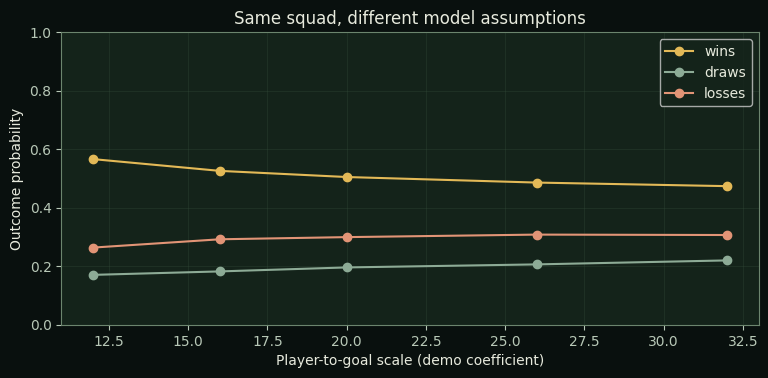

In [8]:
TRIALS = 5000
series = simulate_series(team, rival, n=TRIALS, seed=MATCH_SEED)
probability_table = pd.DataFrame([{"Outcome": key, "Probability": p,
    "Sampling lower": series["sampling_intervals"][key][0],
    "Sampling upper": series["sampling_intervals"][key][1]}
    for key,p in series["probabilities"].items()])
display(probability_table.round(4))
print(series["interval_note"])

sensitivity = []
for scale in [12.0, 16.0, 20.0, 26.0, 32.0]:
    cfg = replace(CONFIG, role_scale=scale)
    trial = simulate_series(team, rival, n=TRIALS, seed=MATCH_SEED, config=cfg)
    sensitivity.append({"Goal-rate scale": scale, **trial["probabilities"],
        "Expected home goals": trial["home_xg"], "Expected away goals": trial["away_xg"]})
sensitivity = pd.DataFrame(sensitivity)
display(sensitivity.round(4))
fig, ax = plt.subplots(figsize=(9,3.8))
for column,color in [("wins","#e3b957"),("draws","#8dab96"),("losses","#e29476")]:
    ax.plot(sensitivity["Goal-rate scale"], sensitivity[column], marker="o", label=column, color=color)
ax.set(xlabel="Player-to-goal scale (demo coefficient)", ylabel="Outcome probability", ylim=(0,1),
    title="Same squad, different model assumptions")
ax.legend(facecolor="#14231a", labelcolor="#e7eadd"); ax.grid(alpha=.3); plt.show()

## Season laboratory

The original editable 38-match experiment samples generated rivals with the same engine. It is separate from Era Gauntlet's four segments, management choices, boss series and retries, and separate from The League career.

In [9]:
opponents = []
for i in range(38):
    other = DraftGame(players, era=ERA, seed=DRAFT_SEED + 200000 + i, config=CONFIG)
    for _ in range(5): other.spin()
    opponents.append(other.lineup())
season = simulate_season(team, opponents, seed=MATCH_SEED)
display(pd.DataFrame([{k:season[k] for k in ["wins","draws","losses","points","best_unbeaten"]}]))
display(pd.DataFrame(season["matches"]).head(10).round(2))
print(season["label"])

,wins,draws,losses,points,best_unbeaten
0,19,7,12,64,7


,match,opponent,outcome,goals_for,goals_against,xg_for,xg_against
0,1,Pep Guardiola,L,2,3,1.06,2.87
1,2,Vicente del Bosque,W,4,1,1.41,2.41
2,3,Arrigo Sacchi,W,2,1,2.04,1.83
3,4,Lionel Scaloni,L,0,4,1.05,2.43
4,5,Zinedine Zidane,L,2,3,0.92,1.64
5,6,Vicente del Bosque,W,2,1,2.45,0.69
6,7,Jürgen Klopp,W,3,2,1.67,1.27
7,8,Lionel Scaloni,W,2,0,1.57,0.55
8,9,Jürgen Klopp,D,1,1,1.27,1.85
9,10,Carlo Ancelotti,L,0,2,0.67,1.60


Synthetic drafted opponents; not historical club-season fixtures.


## 8. Edit players, role weights, or import another edition

The model does not rewrite source ratings. Make a copy to experiment. Custom role weights use the order `pace, shooting, passing, dribbling, defending, physical` and are normalized to sum to one.

The EA importer accepts a SoFIFA-style career CSV with detailed attributes when supplied. The PES importer accepts a CSV with fields such as `Name`, `Position`, `Overall`, `Speed`, `Finishing`, `Low Pass`, and `Defensive Awareness`. It stores its aggregation map and labels the resulting groups as PES proxies. FC and PES aggregate scales are not assumed statistically equivalent. Each importer rejects missing required ratings rather than silently substituting zeros.

User exports and caches belong in the ignored `data/local/` directory. Supply only data you are entitled to use; those files are never needed for the bundled offline game.

In [10]:
edited_players = copy.deepcopy(players)
selected = next(p for p in edited_players if p["name"] == "Lionel Messi" and p["era"] == "2020s")
original_pace = selected["pace"]
selected["pace"] = min(99, selected["pace"] + 5)
selected["lineage"] = "user-edited-experiment"
validate_players(edited_players)
print(f"Experimental Messi pace: {original_pace} → {selected['pace']}. Original source pool is unchanged.")

custom_weights = copy.deepcopy(ROLE_WEIGHTS)
custom_weights["ST"] = (0.12, 0.55, 0.12, 0.10, 0.01, 0.10)
alternative = draft.lineup(weights=custom_weights)
display(pd.DataFrame([{"Setting": label, "Mean role score": rate_team(t)["role_quality"]}
    for label,t in [("Default weights",team),("Finishing-first striker weights",alternative)]]))

# Example imports, after saving your exports into data/local/:
# ea_players = import_ea_csv(ROOT / "data/local/male_players.csv", era="2020s", edition=24)
# pes_players = import_pes_csv(ROOT / "data/local/pes_players.csv", era="2000s")
# imported_lab = NotebookGame(ea_players, config=CONFIG, seed=42).display()

Experimental Messi pace: 80.0 → 85.0. Original source pool is unchanged.


,Setting,Mean role score
0,Default weights,79.827345
1,Finishing-first striker weights,79.805527


## 9. Optional real-match analytics

This section analyzes **Argentina v France, World Cup final, 18 December 2022**, using [StatsBomb Open Data](https://github.com/statsbomb/open-data). Turn `RUN_REAL_EVENTS` on to fetch the raw file into an ignored local cache. The game itself runs offline.

StatsBomb's [data agreement](https://github.com/statsbomb/open-data/blob/master/LICENSE.pdf) applies to downloaded events and restricts commercial use and redistribution. The public repository includes no raw StatsBomb events. Analysis is attributed to StatsBomb with its logo.

Measured shot xG, non-penalty xG, shot-linked xA, pass completion, pressures, and forward movement are distinct from game simulation statistics. Shootout events are excluded. Scheduled playing minutes include extra time and exclude stoppage. A forward move means a successful pass or carry with at least ten metres of forward x displacement; it is not FBref's progressive-pass definition. A single match cannot establish a reliable per-90 player ranking.

The xT grid implements [Karun Singh's expected-threat fixed point](https://karun.in/blog/expected-threat.html), using empirical goal frequencies and absorbing failed moves. Empty cells remain zero. This one-match field demonstrates the method; it is too sparse to calibrate the game or rank careers.

In [11]:
RUN_REAL_EVENTS = False          # Set True and rerun this cell to fetch/analyze the final
from era_eleven.events import load_statsbomb, event_metrics, fit_expected_threat, LOGO

if RUN_REAL_EVENTS:
    events = load_statsbomb(3869685, cache_dir=ROOT / "data/local")
    measured = event_metrics(events)
    display(HTML(f'<img src="{LOGO}" alt="StatsBomb" style="max-width:190px;background:white;padding:10px"><p>Data: StatsBomb Open Data. Argentina v France, 18 December 2022.</p>'))
    display(measured[["player","team","scheduled_minutes","xg","npxg","xa","xg_per90",
        "pass_completion","forward_moves_10m","pressures"]].round(3).head(15))
    print(measured.attrs)
    xt = fit_expected_threat(events)
    fig, ax = plt.subplots(figsize=(9,5))
    image = ax.imshow(xt["grid"], origin="lower", cmap="YlGn", extent=[0,105,0,68])
    ax.set(xlabel="Attacking direction → (metres)", ylabel="Pitch width (metres)",
        title="Illustrative single-match expected threat · StatsBomb")
    fig.colorbar(image, ax=ax, label="Expected future goals from zone")
    plt.show()
    print({k:v for k,v in xt.items() if k!="grid"})
else:
    print("Optional real-event analysis is off. Set RUN_REAL_EVENTS=True to load it; the offline game is fully available.")

Optional real-event analysis is off. Set RUN_REAL_EVENTS=True to load it; the offline game is fully available.


## 10. Save your experiment

Exports are local and ignored by Git. The JSON records the squad, assignment, model configuration, seeds, and sampled match. Reopen it to compare experiments or report an unexpected result. The final assertion checks the serialized file.

In [12]:
EXPORTS = ARTIFACT_ROOT
EXPORTS.mkdir(parents=True,exist_ok=True)
export_path = EXPORTS / f"Era Eleven {ERA} seed {DRAFT_SEED}.json"
payload = {"draft_seed":DRAFT_SEED,"era":ERA,"config":asdict(CONFIG),"squad":draft.squad,
    "team":team,"opponent":rival,"match_seed":MATCH_SEED,"match":result,"series":series}
export_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
restored = json.loads(export_path.read_text(encoding="utf-8"))
assert len(restored["squad"]) == 15 and len(restored["team"]["bench"]) == 4
print("Saved and re-read:", export_path.name)

Saved and re-read: Era Eleven All eras seed 42.json


## Sources, evidence and scope

The [data manifest](data/manifest.json) and [data pipeline](docs/DATA_PIPELINE.md) retain publisher, edition, source IDs, licences, missingness and attribute mappings. Similar names do not merge people. Classics cannot supply a full independent squad; its cards remain in Legends and All eras.

The [integration audit](docs/INTEGRATION.md) describes the pinned `fas` dependency and why legal substitutions, role assignment and the unique local event estimator remain active. The [feature matrix](docs/FEATURE_MATRIX.md) separates observed Eraball behavior from football adaptations and inaccessible reference branches. The [validation record](docs/VALIDATION.md) describes workflow checks.

Saved browser/notebook modes use one Python authority. Rankings, rooms, profiles and progress are scoped to that running server/database; this repository does not host a global account or matchmaking service. A notebook `:memory:` service is an isolated experiment. Persist it with an explicit SQLite path to resume later.

## Saved modes and shared game controls

Choose a single eligible era with **Randomize Era**, or use **All eras** for a mixed player pool. Equal random-era weights are the default and can be edited below. The chosen pool and all seeds persist in each run. Weekly Challenge overrides editable draft conditions with a versioned UTC week, fixed tier quotas and generated rivals.

Era Gauntlet retains the fifteen drafted people, permits one management choice between fourteen-game segments, and repeats a lost boss act while patience remains. The Tournament Circuit contains 10–20 events across league, group, knockout, aggregate and best-of formats; awards come from actual simulated outcomes. Boss and tournament victories unlock a trophy album distinct from the draft album.

The League creates a fictional football avatar anchored to a sourced card. Four d20 decisions surround every shared-engine match, with earned XP, office choices, teammates and retirement. Its twenty-level ending simplifies the audited basketball career. The controls and programmatic examples call the same service routes as the browser.

`STATE_PATH=':memory:'` makes this execution an isolated notebook experiment. Change it to a persistent path before starting a real notebook career. The service keeps credentials private; displayed results and public replay recipes omit them.

In [13]:
from copy import deepcopy
from era_eleven.service import GameService
from era_eleven.widgets import NotebookModes

MODE_SEED=42
STATE_PATH=':memory:'                 # e.g. ROOT/'data'/'local'/'notebook.sqlite'
RANDOM_ERA_WEIGHTS={era:1.0 for era in ['Legends','1990s','2000s','2010s','2020s']}
CHALLENGE_RULES=json.loads((ROOT/'data'/'challenge_rules.json').read_text(encoding='utf-8'))
# Edit CHALLENGE_RULES deliberately; its contents are part of the comparison version.
SERVICE=GameService(players=players,state_path=STATE_PATH,challenge_rules=CHALLENGE_RULES)
MODES=NotebookModes(service=SERVICE,config=CONFIG,seed=MODE_SEED).display()


### Programmatic saved run

Each spin adds all three revealed cards. This service example is also a reproducible browser replay: the run's data, model and rules version is checked at import. Imported experiments remain unranked. Editable inputs below are genuine engine settings; they do not fit a model.

In [14]:
PROFILE=SERVICE.call('profile')['profile']
MODE='solo'                           # solo, weekly, gauntlet, circuit, league (season laboratory)
POOL='Randomize Era'                  # eligible single era; 'All eras' is a mixed pool
saved=SERVICE.call('new',dict(profile=PROFILE,mode=MODE,era=POOL,seed=MODE_SEED,
                              config=asdict(CONFIG),random_era_weights=RANDOM_ERA_WEIGHTS,
                              gauntlet_map='three',tournaments=15))
for turn in range(5):
    saved=SERVICE.call('spin',dict(profile=PROFILE,token=saved['token'],action_id=f'notebook-spin-{turn}'))
assert saved['count']==15 and len({p['identity'] for p in saved['squad']})==15
display(pd.DataFrame(saved['squad'])[['name','era','positions','overall']])
display(pd.DataFrame([saved['analytics']['rating']]).drop(columns=['fallback_players'],errors='ignore'))
print('Chosen pool:',saved['era'],'| manager:',saved['manager']['name'],'| formation:',saved['formation'])
print('Rules/data/model:',saved['version'])
public_recipe=SERVICE.call('export',dict(profile=PROFILE,token=saved['token']))
# public_recipe is a recipe, never an accepted client-supplied score or team rating.


,name,era,positions,overall
0,K. De Bruyne,2010s,"[CAM, CM, RM]",89
1,G. Cahill,2010s,[CB],84
2,Kylian Mbappé,2010s,[ST],83
3,İ. Gündoğan,2010s,"[CM, CDM]",85
4,F. Ribéry,2010s,"[LM, LW]",86
5,Naldo,2010s,[CB],82
6,J. Rodríguez,2010s,"[CAM, CM, RM]",86
7,A. Florenzi,2010s,"[RB, RW, CM]",82
8,C. Eriksen,2010s,"[CAM, RM, LM]",87
9,J. Milner,2010s,"[LB, CM]",80


,attack,control,defence,keeper,role_quality,role_fit,chemistry,tactical_fit,stamina,stamina_fallbacks,links,model
0,81.245456,85.868123,78.761376,81.96,78.392073,0.989091,0.904782,0.1882,80.8,[],"[{'a': 'ea-138412-18', 'b': 'ea-184087-18', 'v...",uncalibrated attributes + tactical/chemistry p...


Chosen pool: 2010s | manager: Zinedine Zidane | formation: 4-3-3
Rules/data/model: football-4:95d79c09a1b6d13e6c38


### Two-human head to head

Two seats use independent seeded drafts and the authority validates every action. A local room alternates turns on one device; an online room permits simultaneous independent drafts and hides the opponent's cards until both are ready. The reference's basketball seasons become a neutral football match. Public account matchmaking needs an external service and is not claimed here.

This isolated example finishes a real local two-seat workflow through the room API; the browser provides the handover screen. Credentials below are private runtime objects and are not printed or included in public result exports.

In [15]:

room=SERVICE.call('room/create',dict(profile=PROFILE,local=True,era='2020s',seed=MODE_SEED))
seats=room['local_credentials']
for pick in range(10):
    seat=pick%2
    room=SERVICE.call('room/spin',dict(room=room['room'],credential=seats[seat],action_id=f'local-{pick}'))
for seat in range(2):
    room=SERVICE.call('room/ready',dict(room=room['room'],credential=seats[seat],action_id=f'ready-{seat}'))
display(HTML(wrap(result_html(room['result']))))
assert room['phase']=='finished'


## Inspect source coverage and the analytics boundary

Provider IDs identify people; card IDs identify editions. Imports retain mappings, missing source columns and licence declarations. `pool_report` checks role coverage and reports missingness; salary and tier feasibility is enforced by the actual constrained draft. Attribute similarity is descriptive and does not alter chemistry. The match prediction uses the same fatigue/substitution rates as simulation.

In [16]:
from era_eleven.data import pool_report
from era_eleven.analytics import (backend_status, matchup_analysis, player_record,
                                  team_record, attribute_compatibility, analyse_events, evaluate_results)
coverage=pool_report(players,CONFIG)
display(pd.DataFrame([dict(era=e,eligible=v['eligible'],people=v['people'],reason=v['reason'])
                     for e,v in coverage['eras'].items()]))
display(pd.Series(coverage['missing_attributes'],name='Missing source attributes'))
status=backend_status()
print('Scoring backend:',status['backend'],'| audited module matches:',status['scoring_module_matches_audit'])
print(status['label'])
prediction=matchup_analysis(team,rival,CONFIG)
display(pd.DataFrame([prediction['probabilities']]))
print(prediction['uncertainty'])
if status['available']:
    card_entity=player_record(team['starters'][0]['player'])
    squad_entity=team_record(team)
    print('Entity mapping preserves',len(squad_entity.squad),'people; measured-event data:',card_entity.performance['event_measurements_available'])
    compatibility=attribute_compatibility(team)
    display(compatibility['matrix'].round(3))
    print(compatibility['label'],'| affects gameplay:',compatibility['affects_gameplay'])


,era,eligible,people,reason
0,All eras,True,551,
1,Legends,True,157,
2,1990s,True,46,
3,2000s,True,89,
4,2010s,True,239,
5,2020s,True,229,
6,Classics,False,22,Pre-1990 subset lacks full formation coverage....


pace               68
shooting           68
passing            68
dribbling          68
defending          68
physical           68
gk_diving         150
gk_handling       150
gk_kicking        150
gk_reflexes       150
gk_speed          557
gk_positioning    150
stamina           157
vision            157
finishing         157
Name: Missing source attributes, dtype: int64

Scoring backend: fas | audited module matches: True
Fixed attribute, role, tactical and chemistry assumptions; not fitted to match results.


,home,draw,away
0,0.495793,0.19643,0.307777


Score probabilities include simulation randomness. They exclude uncertainty in ratings, era mappings and fixed model assumptions.
Entity mapping preserves 15 people; measured-event data: False


,ea-189332-24,ea-253163-24,icon-carles-puyol-saforcada,ea-226851-24,ea-20775-18,icon-patrick-vieira,ea-216352-24,ea-235212-24,ea-231478-24,icon-jay-jay-okocha
ea-189332-24,1.000,0.982,0.972,0.993,0.950,0.995,0.994,0.999,0.980,0.976
ea-253163-24,0.982,1.000,0.998,0.994,0.891,0.991,0.981,0.985,0.954,0.925
icon-carles-puyol-saforcada,0.972,0.998,1.000,0.991,0.868,0.985,0.976,0.974,0.939,0.905
ea-226851-24,0.993,0.994,0.991,1.000,0.914,0.998,0.996,0.991,0.968,0.947
ea-20775-18,0.950,0.891,0.868,0.914,1.000,0.930,0.934,0.952,0.976,0.993
icon-patrick-vieira,0.995,0.991,0.985,0.998,0.930,1.000,0.997,0.995,0.980,0.960
ea-216352-24,0.994,0.981,0.976,0.996,0.934,0.997,1.000,0.991,0.978,0.963
ea-235212-24,0.999,0.985,0.974,0.991,0.952,0.995,0.991,1.000,0.985,0.976
ea-231478-24,0.980,0.954,0.939,0.968,0.976,0.980,0.978,0.985,1.000,0.987
icon-jay-jay-okocha,0.976,0.925,0.905,0.947,0.993,0.960,0.963,0.976,0.987,1.000


Cosine similarity of game attributes; descriptive only, not measured team chemistry. | affects gameplay: False


### Optional fas event analysis

Enable the earlier `RUN_REAL_EVENTS` cell to load attributed StatsBomb events, then rerun this cell. This exposes passing networks, event profiles and the upstream xT estimator. Its transition denominator excludes failed moves; the retained local estimator absorbs failed moves as turnovers. Their values can differ. An xT field fitted to its own analysed match is descriptive. It does not validate forecasting, and the simulated shot log is never presented as measured spatial data.

In [17]:
if RUN_REAL_EVENTS and status['available']:
    shared_events=analyse_events(events,match_id=3869685,
                                  evidence='StatsBomb Open Data: 2022 World Cup final; same-match descriptive fit')
    display(shared_events['summary'])
    print(shared_events['limitation'])
else:
    print('No event download requested. Enable RUN_REAL_EVENTS and install the pinned dependency for these optional tools.')


No event download requested. Enable RUN_REAL_EVENTS and install the pinned dependency for these optional tools.


### Historical forecasting assessment

The separate assessment fitted `fas` team strengths on 48 World Cup 2022 group matches before 3 December and evaluated on 16 later knockout matches. It **did not beat the training mean baseline** on negative log likelihood, outcome Brier score or home-win calibration error. This small holdout uses team IDs and match-record scores, which may include extra time; it does not validate drafted cross-era squads. The fitted result does not affect gameplay. [Evaluation metadata](docs/evaluation.json) records the split, hash, pin and metrics; raw inputs remain outside the repository.

StatsBomb Open Data supplied the match records. [Source and data agreement](https://github.com/statsbomb/open-data). Attribution and source logo are retained below.

![StatsBomb](https://raw.githubusercontent.com/statsbomb/open-data/master/img/SB%20-%20Icon%20Lockup%20-%20Colour%20positive.png)

To assess your own permitted dated results, set `RUN_FITTED_RESULTS=True`, supply the CSV path, and choose the split. Required columns are `date, home_team, away_team, home_goals, away_goals`. Team IDs must be numeric and known in the earlier training period.

In [18]:
assessment_metadata=json.loads((ROOT/'docs'/'evaluation.json').read_text(encoding='utf-8'))
display(pd.DataFrame(assessment_metadata['metrics']))
RUN_FITTED_RESULTS=False
RESULTS_CSV=ROOT/'data'/'local'/'permitted_results.csv'
TRAIN_EVALUATION_SPLIT='2024-01-01'
if RUN_FITTED_RESULTS:
    assessment=evaluate_results(pd.read_csv(RESULTS_CSV),split_date=TRAIN_EVALUATION_SPLIT)
    display(assessment['metrics'])
    print(assessment['limitation'])


,model,poisson_nll,brier,home_ece
0,fas time-split Poisson,3.876149,0.628856,0.314364
1,training mean baseline,3.231891,0.627384,0.219779
